In [1]:
!pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.9.0+cpu
Uninstalling torch-2.9.0+cpu:
  Successfully uninstalled torch-2.9.0+cpu
Found existing installation: torchvision 0.24.0+cpu
Uninstalling torchvision-0.24.0+cpu:
  Successfully uninstalled torchvision-0.24.0+cpu
Found existing installation: torchaudio 2.9.0+cpu
Uninstalling torchaudio-2.9.0+cpu:
  Successfully uninstalled torchaudio-2.9.0+cpu


In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
     ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
     - -------------------------------------- 0.3/6.2 MB ? eta -:--:--
     - -------------------------------------- 0.3/6.2 MB ? eta -:--:--
     -------- ------------------------------- 1.3/6.2 MB 2.3 MB/s eta 0:00:03
     ------------- -------------------------- 2.1/6.2 MB 2.9 MB/s eta 0:00:02
     -------------------- ------------------- 3.1/6.2 MB 3.4 MB/s eta 0:00:01
     --------------------------- ------------ 4.2/6.2 MB 3.6 MB/s eta 0:00:01
     --------------------------------- ------ 5.2/6.2 MB 3.8 MB/s eta 0:00:01
     -------------------------------------- - 6.0/6.2 MB 4.0 MB/s eta 0:00:01
     ---------------------------------------- 6.2/6.2 MB 3.8 MB/s  0:00:01

  Attempting uninstall: sympy

    Found existing installation: sympy 1.14.0

   ---------------------------------------- 0/2 [sympy]
   ---------------------------------------- 0/2 [sym

Training samples: 73376
Validation samples: 18344
Test samples: 7628
Train samples: 91720


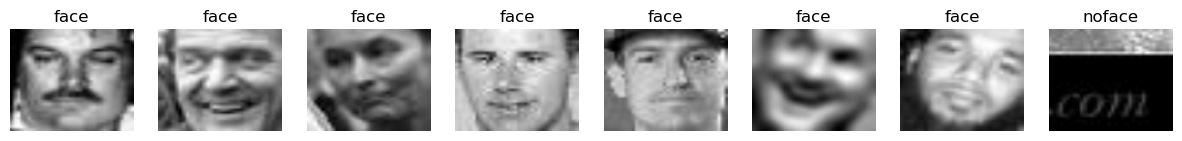

In [17]:
import os
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data.sampler import SubsetRandomSampler
from PIL import Image
import matplotlib.pyplot as plt

# Paths to your dataset
train_dir = r"C:\Users\lingz\Documents\face-detector\deep\data\train_images"    # folder containing training images
test_dir  = r"C:\Users\lingz\Documents\face-detector\deep\data\test_images"     # folder containing test images

# Define transformations (convert to gray-scale, tensor, normalize)
transform = transforms.Compose(
    [transforms.Grayscale(),   # transforms to gray-scale (1 input channel)
     transforms.Resize((92, 112)),  # match the original calculation
     transforms.ToTensor(),    # transforms to Torch tensor (needed for PyTorch)
     transforms.Normalize(mean=(0.5,), std=(0.5,))]) # subtracts mean (0.5) and divides by std (0.5) -> resulting values in (-1, +1)

# Define two pytorch datasets (train/test) 
train_data = torchvision.datasets.ImageFolder(train_dir, transform=transform)
test_data  = torchvision.datasets.ImageFolder(test_dir, transform=transform)

valid_size = 0.2   # proportion of validation set (80% train, 20% validation)
batch_size = 32    

# Define randomly the indices of examples to use for training and for validation
num_train = len(train_data)
indices_train = list(range(num_train))
np.random.shuffle(indices_train)
split_tv = int(np.floor(valid_size * num_train))
train_new_idx, valid_idx = indices_train[split_tv:], indices_train[:split_tv]

# subset_size = 500  # number of images you want to use for quick test
# train_new_idx = train_new_idx[:subset_size]
# valid_idx = valid_idx[:int(subset_size*0.2)]  # keep 20% for validation



# Define two "samplers" that will randomly pick examples from the training and validation set
train_sampler = SubsetRandomSampler(train_new_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# Dataloaders (take care of loading the data from disk, batch by batch, during training)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, sampler=train_sampler, num_workers=1)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, sampler=valid_sampler, num_workers=1)
test_loader  = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=1)

classes = ('noface','face')  # indicates that "1" means "face" and "0" non-face (only used for display)

# Quick check: see number of examples
print(f"Training samples: {len(train_new_idx)}")
print(f"Validation samples: {len(valid_idx)}")
print(f"Test samples: {len(test_data)}")
print(f"Train samples: {len(train_data)}")


# Visualize a few images from the training dataset
def show_images(loader, num_images=8):
    data_iter = iter(loader)
    images, labels = next(data_iter)
    fig, axes = plt.subplots(1, num_images, figsize=(15,3))
    for i in range(num_images):
        img = images[i].squeeze().numpy()  # remove channel dimension
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(classes[labels[i]])
        axes[i].axis('off')
    plt.show()

show_images(train_loader)


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Conv layers: input channels=1 (grayscale), output channels=16, kernel 3x3
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)
        # Fully connected layers (flattened feature maps -> neurons)
        self.fc1 = nn.Linear(32*23*28, 128)  # adjust based on output of conv+pool
        self.fc2 = nn.Linear(128, 2)         # 2 classes: face/no face

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # conv1 -> relu -> pool
        x = self.pool(F.relu(self.conv2(x)))  # conv2 -> relu -> pool
        x = x.view(x.size(0), -1)  # x.size(0) = batch size
        x = F.relu(self.fc1(x))              # FC1 -> relu
        x = self.fc2(x)                      # FC2 -> output
        return x


In [19]:
# Loss funciton n stuff
import torch.optim as optim

model = SimpleCNN()
criterion = nn.CrossEntropyLoss()  # for 2-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [20]:
from tqdm import tqdm
import torch

# ============================================================
# TWEAKABLE SETTINGS - Change these to improve your model
# ============================================================
N_EPOCHS = 5           # More epochs = more training (try 15-30)
LEARNING_RATE = 0.001   # How fast model learns (try 0.0005 or 0.002)
SAVE_BEST = True        # Only save model when it improves
MODEL_PATH = "model_best.pth"

# ============================================================
# TRAINING LOOP
# ============================================================
best_accuracy = 0.0

for epoch in range(N_EPOCHS):
    # ==================== TRAINING ====================
    model.train()
    running_loss = 0.0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{N_EPOCHS}"):
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    
    # ==================== VALIDATION ====================
    model.eval()
    valid_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in valid_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            valid_loss += loss.item()
            
            _, predictions = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()
    
    avg_valid_loss = valid_loss / len(valid_loader)
    accuracy = correct / total * 100
    
    # ==================== PRINT RESULTS ====================
    print(f"\nEpoch {epoch+1}/{N_EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Valid Loss: {avg_valid_loss:.4f}")
    print(f"  Valid Accuracy: {accuracy:.2f}%")
    
    # ==================== SAVE MODEL ====================
    if SAVE_BEST:
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            torch.save(model.state_dict(), MODEL_PATH)
            print(f"  ✓ New best model saved! (Acc: {accuracy:.2f}%)")
    else:
        torch.save(model.state_dict(), MODEL_PATH)

print(f"\nTraining complete! Best accuracy: {best_accuracy:.2f}%")

Epoch 1/5: 100%|███████████████████████████████████████████████████████████████████| 2293/2293 [24:29<00:00,  1.56it/s]


Epoch 1, Training Loss: 0.05595090514262799
Epoch 1, Validation Loss: 0.0222, Validation Accuracy: 99.18%


Epoch 2/5: 100%|███████████████████████████████████████████████████████████████████| 2293/2293 [03:00<00:00, 12.70it/s]


Epoch 2, Training Loss: 0.01428233847618474
Epoch 2, Validation Loss: 0.0137, Validation Accuracy: 99.51%


Epoch 3/5: 100%|███████████████████████████████████████████████████████████████████| 2293/2293 [02:59<00:00, 12.77it/s]


Epoch 3, Training Loss: 0.008940393449344977
Epoch 3, Validation Loss: 0.0125, Validation Accuracy: 99.54%


Epoch 4/5: 100%|███████████████████████████████████████████████████████████████████| 2293/2293 [03:01<00:00, 12.60it/s]


Epoch 4, Training Loss: 0.005493848716473253
Epoch 4, Validation Loss: 0.0103, Validation Accuracy: 99.65%


Epoch 5/5: 100%|███████████████████████████████████████████████████████████████████| 2293/2293 [02:59<00:00, 12.76it/s]


Epoch 5, Training Loss: 0.003428754497301524
Epoch 5, Validation Loss: 0.0115, Validation Accuracy: 99.68%


In [21]:
model.load_state_dict(torch.load("model_final.pth"))

C:\Users\lingz\AppData\Local\Temp\ipykernel_21508\2078784548.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model_final.pth"))


<All keys matched successfully>

In [22]:
import torch
from tqdm import tqdm

model.eval()  # evaluation mode
correct = 0
total = 0

with torch.no_grad():  # no gradients needed in testing
    # wrap loader in tqdm for progress bar
    for images, labels in tqdm(test_loader, desc="Testing"):
        outputs = model(images)                          # forward pass
        _, predictions = torch.max(outputs, 1)           # pick class with highest score
        total += labels.size(0)                          # count total samples
        correct += (predictions == labels).sum().item()  # count correct predictions

accuracy = correct / total * 100
print(f"Test Accuracy: {accuracy:.2f}%")


Testing: 100%|███████████████████████████████████████████████████████████████████████| 239/239 [00:19<00:00, 12.23it/s]

Test Accuracy: 93.55%


In [23]:

print("hello1")

hello1


In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms, ops
from PIL import Image
import numpy as np

# -----------------------------
# MAIN CONFIGURATION - CHANGE THESE!
# -----------------------------
class DetectionConfig:
    """All detection parameters in one place"""
    
    # Sliding window settings
    STEP_SIZE = 16              # How many pixels to move window (higher = faster, less thorough)
    WINDOW_SIZE = (112, 92)     # (width, height) - should match your model's training size
    
    # Threshold settings
    SCORE_THRESHOLD = 0.65      # Min confidence to keep detection (0.0-1.0, higher = fewer detections)
    NMS_THRESHOLD = 0.2         # IoU threshold for removing overlaps (lower = more aggressive)
    
    # Image pyramid settings
    PYRAMID_SCALE = 1.2         # How much to shrink each level (1.2 = 20% smaller)
    MIN_PYRAMID_SIZE = (112, 92)  # Stop pyramid when image gets this small
    
    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Model input transform
    TRANSFORM = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((92, 112)),  # (height, width) for transforms
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,), std=(0.5,))
    ])

# Quick presets you can use
class Presets:
    """Pre-configured settings for common scenarios"""
    
    @staticmethod
    def fast():
        """Fast detection, may miss some faces"""
        config = DetectionConfig()
        config.STEP_SIZE = 30
        config.SCORE_THRESHOLD = 0.7
        config.NMS_THRESHOLD = 0.2
        return config
    
    @staticmethod
    def balanced():
        """Good balance of speed and accuracy"""
        config = DetectionConfig()
        config.STEP_SIZE = 20
        config.SCORE_THRESHOLD = 0.65
        config.NMS_THRESHOLD = 0.2
        return config
    
    @staticmethod
    def thorough():
        """Slower but catches more faces"""
        config = DetectionConfig()
        config.STEP_SIZE = 12
        config.SCORE_THRESHOLD = 0.5
        config.NMS_THRESHOLD = 0.3
        return config
    
    @staticmethod
    def precise():
        """Very selective, minimal false positives"""
        config = DetectionConfig()
        config.STEP_SIZE = 20
        config.SCORE_THRESHOLD = 0.8
        config.NMS_THRESHOLD = 0.15
        return config


# -----------------------------
# Detection Functions
# -----------------------------
def sliding_window(image, model, config):
    """Slide window over image and detect faces"""
    detections = []
    img_np = np.array(image)
    H, W = img_np.shape[:2]
    
    window_width, window_height = config.WINDOW_SIZE

    for y in range(0, H - window_height + 1, config.STEP_SIZE):
        for x in range(0, W - window_width + 1, config.STEP_SIZE):
            # Extract and process patch
            patch = image.crop((x, y, x + window_width, y + window_height))
            patch_tensor = config.TRANSFORM(patch).unsqueeze(0).to(config.DEVICE)

            with torch.no_grad():
                output = model(patch_tensor)
                prob = torch.softmax(output, dim=1)
                score = prob[0, 1].item()

            if score >= config.SCORE_THRESHOLD:
                detections.append((x, y, x + window_width, y + window_height, score))

    return detections


def image_pyramid(image, config):
    """Generate multi-scale versions of the image"""
    pyramid = [image]  # Start with original
    current = image
    
    while True:
        w = int(current.size[0] / config.PYRAMID_SCALE)
        h = int(current.size[1] / config.PYRAMID_SCALE)
        
        if w < config.MIN_PYRAMID_SIZE[0] or h < config.MIN_PYRAMID_SIZE[1]:
            break
            
        current = current.resize((w, h), Image.BILINEAR)
        pyramid.append(current)
    
    return pyramid


def detect_faces(image, model, config=None, verbose=True):
    """
    Main detection function - detects faces at multiple scales.
    
    Args:
        image: PIL Image (grayscale or RGB)
        model: trained face detection model
        config: DetectionConfig object (uses default if None)
        verbose: print detection progress
    
    Returns:
        List of (x1, y1, x2, y2, score) tuples
    """
    if config is None:
        config = DetectionConfig()
    
    model.eval()
    
    # Convert to grayscale if needed
    if image.mode != 'L':
        image = image.convert('L')
    
    all_detections = []

    # Generate image pyramid
    pyramid = image_pyramid(image, config)
    
    if verbose:
        print(f"Processing {len(pyramid)} pyramid levels...")

    for level_idx, scaled_image in enumerate(pyramid):
        # Calculate scale factors to map back to original
        scale_w = image.width / scaled_image.width
        scale_h = image.height / scaled_image.height

        # Run sliding window
        detections = sliding_window(scaled_image, model, config)

        if verbose:
            print(f"  Level {level_idx}: {scaled_image.size}, found {len(detections)} candidates")

        # Map boxes back to original image coordinates
        for x1, y1, x2, y2, score in detections:
            all_detections.append((
                int(x1 * scale_w),
                int(y1 * scale_h),
                int(x2 * scale_w),
                int(y2 * scale_h),
                score
            ))

    if verbose:
        print(f"Total candidates before NMS: {len(all_detections)}")

    # Apply NMS
    if not all_detections:
        return []

    boxes = torch.tensor([[x1, y1, x2, y2] for x1, y1, x2, y2, score in all_detections],
                         dtype=torch.float, device=config.DEVICE)
    scores = torch.tensor([score for x1, y1, x2, y2, score in all_detections],
                          dtype=torch.float, device=config.DEVICE)

    keep = ops.nms(boxes, scores, iou_threshold=config.NMS_THRESHOLD)

    final_boxes = boxes[keep]
    final_scores = scores[keep]

    if verbose:
        print(f"Final detections after NMS: {len(final_boxes)}")

    return [(int(x1.item()), int(y1.item()), int(x2.item()), int(y2.item()), score.item()) 
            for (x1, y1, x2, y2), score in zip(final_boxes, final_scores)]


# -----------------------------
# Usage Examples
# -----------------------------
if __name__ == "__main__":
    """
    # Option 1: Use default settings
    detections = detect_faces(image_pil, model)
    
    # Option 2: Use a preset
    config = Presets.balanced()  # or .fast(), .thorough(), .precise()
    detections = detect_faces(image_pil, model, config)
    
    # Option 3: Custom settings
    config = DetectionConfig()
    config.STEP_SIZE = 25
    config.SCORE_THRESHOLD = 0.7
    config.NMS_THRESHOLD = 0.2
    detections = detect_faces(image_pil, model, config)
    
    # Option 4: Tweak a preset
    config = Presets.balanced()
    config.SCORE_THRESHOLD = 0.8  # Make it more strict
    detections = detect_faces(image_pil, model, config)
    """
    pass

In [77]:

# ============================================================
# CELL 1: Load Dataset + Ground Truth Bounding Boxes
# ============================================================
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Paths
fddb_root = r"C:\Users\lingz\Documents\face-detector\deep\data\detector_test_images\Dataset_FDDB\Dataset_FDDB\images"
fddb_labels = r"C:\Users\lingz\Documents\face-detector\deep\data\detector_test_images\Dataset_FDDB\Dataset_FDDB\label.txt"
nonface_root = r"C:\Users\lingz\Documents\face-detector\deep\data\test_images"

# Transform
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor(),
])

# Parse ground truth bounding boxes
def parse_fddb_labels(label_file):
    """Parse label.txt file into a dictionary {image_path: [(x1,y1,x2,y2), ...]}"""
    gt_boxes = {}
    
    with open(label_file, 'r') as f:
        lines = f.readlines()
    
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if line.startswith('#'):
            # This is an image path
            img_path = line[2:].strip()  # Remove "# " prefix
            boxes = []
            i += 1
            
            # Read bounding boxes until next # or end
            while i < len(lines) and not lines[i].startswith('#'):
                coords = lines[i].strip().split()
                if len(coords) >= 4:  # Changed from == to >=
                    # Take first 4 values only
                    x1, y1, x2, y2 = map(int, coords[:4])
                    boxes.append((x1, y1, x2, y2))
                elif len(coords) > 0:  # Skip empty lines
                    pass  # Skip lines that don't have 4 coordinates
                i += 1
            
            if boxes:  # Only add if we found boxes
                gt_boxes[img_path] = boxes
        else:
            i += 1
    
    return gt_boxes

# Load ground truth
print("Loading ground truth bounding boxes...")
ground_truth = parse_fddb_labels(fddb_labels)
print(f"Loaded {len(ground_truth)} images with ground truth boxes")

# Custom dataset with ground truth
class FaceDetectionDataset(Dataset):
    def __init__(self, face_root, nonface_root, ground_truth, transform=None):
        self.transform = transform
        self.samples = []
        self.ground_truth = ground_truth
        
        # FDDB faces (with ground truth boxes)
        for year in os.listdir(face_root):
            year_path = os.path.join(face_root, year)
            if not os.path.isdir(year_path):
                continue
            for month in os.listdir(year_path):
                month_path = os.path.join(year_path, month)
                if not os.path.isdir(month_path):
                    continue
                for day in os.listdir(month_path):
                    day_path = os.path.join(month_path, day)
                    if not os.path.isdir(day_path):
                        continue
                    big_path = os.path.join(day_path, "big")
                    if not os.path.isdir(big_path):
                        continue
                    # In Cell 1, modify the dataset class:
                    for fname in os.listdir(big_path):
                        if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.pgm')):
                            fpath = os.path.join(big_path, fname)
                            rel_path = f"{year}/{month}/{day}/big/{fname}"
                            
                            # Only add if we have ground truth for this image
                            if rel_path in self.ground_truth:
                                self.samples.append((fpath, 1, rel_path))

        # uncomment for no face test data useless imo
        """
        # Non-face images (no ground truth)
        for root, _, files in os.walk(nonface_root):
            for fname in files:
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.pgm')):
                    fpath = os.path.join(root, fname)
                    self.samples.append((fpath, 0, None))
    """
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        fpath, label, rel_path = self.samples[idx]
        image = Image.open(fpath).convert("L")
        
        # Get ground truth boxes if available
        gt_boxes = []
        if rel_path and rel_path in self.ground_truth:
            gt_boxes = self.ground_truth[rel_path]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label, gt_boxes, fpath
    
# Create dataset & loader
test_dataset = FaceDetectionDataset(fddb_root, nonface_root, ground_truth, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

print(f"Total test samples: {len(test_dataset)}")
faces = sum([1 for _, label, _ in test_dataset.samples if label == 1])  # 3 values, not 4
nonfaces = len(test_dataset) - faces
print(f"Face images: {faces}, Non-face images: {nonfaces}")

Loading ground truth bounding boxes...
Loaded 2835 images with ground truth boxes
Total test samples: 2835
Face images: 2835, Non-face images: 0


In [82]:
# ============================================================
# CELL 2: Helper Functions for Evaluation
# ============================================================

def compute_iou(box1, box2):
    """
    Compute IoU between two boxes
    box format: (x1, y1, x2, y2)
    """
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2
    
    # Intersection
    x1_i = max(x1_1, x1_2)
    y1_i = max(y1_1, y1_2)
    x2_i = min(x2_1, x2_2)
    y2_i = min(y2_1, y2_2)
    
    if x2_i < x1_i or y2_i < y1_i:
        return 0.0
    
    intersection = (x2_i - x1_i) * (y2_i - y1_i)
    
    # Union
    area1 = (x2_1 - x1_1) * (y2_1 - y1_1)
    area2 = (x2_2 - x1_2) * (y2_2 - y1_2)
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0.0

def match_detections_to_gt(detections, gt_boxes, iou_threshold=0.3):
    """
    Match predicted boxes to ground truth boxes
    Returns: (num_true_positives, num_false_positives, num_false_negatives)
    """
    if len(gt_boxes) == 0 and len(detections) == 0:
        return 0, 0, 0
    
    if len(gt_boxes) == 0:
        return 0, len(detections), 0  # All detections are false positives
    
    if len(detections) == 0:
        return 0, 0, len(gt_boxes)  # Missed all ground truth (false negatives)
    
    # Track which GT boxes have been matched
    gt_matched = [False] * len(gt_boxes)
    true_positives = 0
    false_positives = 0
    
    # For each detection, find best matching GT box
    for det in detections:
        det_box = (det[0], det[1], det[2], det[3])
        best_iou = 0.0
        best_gt_idx = -1
        
        for gt_idx, gt_box in enumerate(gt_boxes):
            if gt_matched[gt_idx]:
                continue
            
            iou = compute_iou(det_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx
        
        if best_iou >= iou_threshold:
            true_positives += 1
            gt_matched[best_gt_idx] = True
        else:
            false_positives += 1
    
    # Unmatched GT boxes are false negatives
    false_negatives = sum([1 for matched in gt_matched if not matched])
    
    return true_positives, false_positives, false_negatives

Evaluating:   0%|                                                                             | 0/2835 [00:00<?, ?it/s]

Processing 7 pyramid levels...
  Level 0: (363, 450), found 2 candidates
  Level 1: (302, 375), found 6 candidates
  Level 2: (251, 312), found 0 candidates
  Level 3: (209, 260), found 2 candidates
  Level 4: (174, 216), found 2 candidates
  Level 5: (145, 180), found 1 candidates
  Level 6: (120, 150), found 0 candidates
Total candidates before NMS: 13
Final detections after NMS: 5


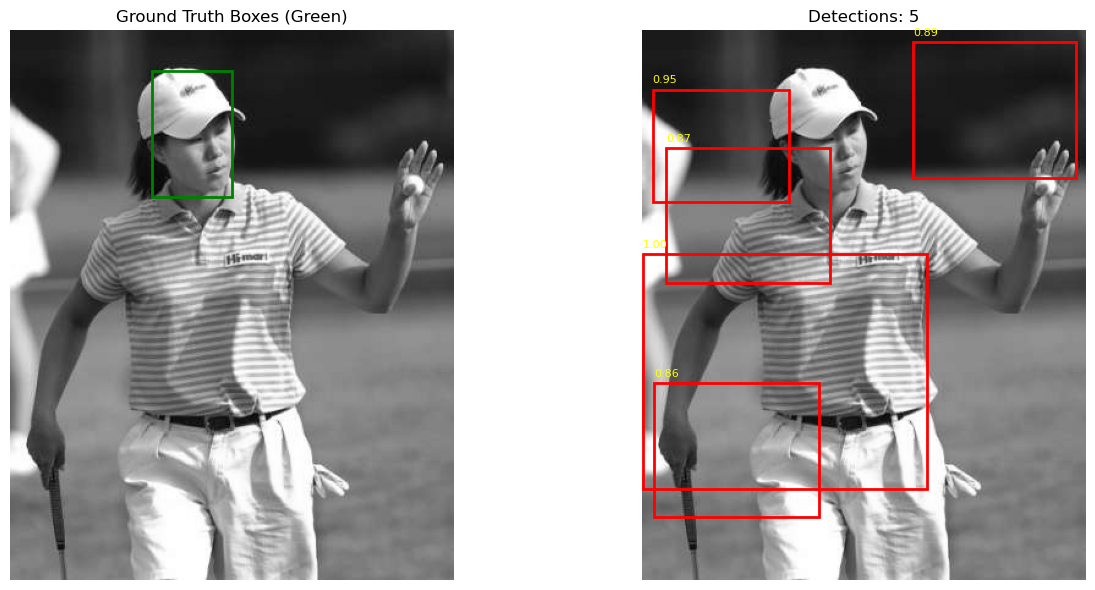

Evaluating:   0%|                                                                   | 1/2835 [00:09<7:31:42,  9.56s/it]


Image 1: img_130.jpg
  Ground Truth Faces: 1
  Detections: 5
  True Positives: 0
  False Positives: 5
  False Negatives: 1
  Recall for this image: 0.0%
Processing 6 pyramid levels...
  Level 0: (335, 450), found 11 candidates
  Level 1: (279, 375), found 10 candidates
  Level 2: (232, 312), found 0 candidates
  Level 3: (193, 260), found 0 candidates
  Level 4: (160, 216), found 0 candidates
  Level 5: (133, 180), found 0 candidates
Total candidates before NMS: 21
Final detections after NMS: 4


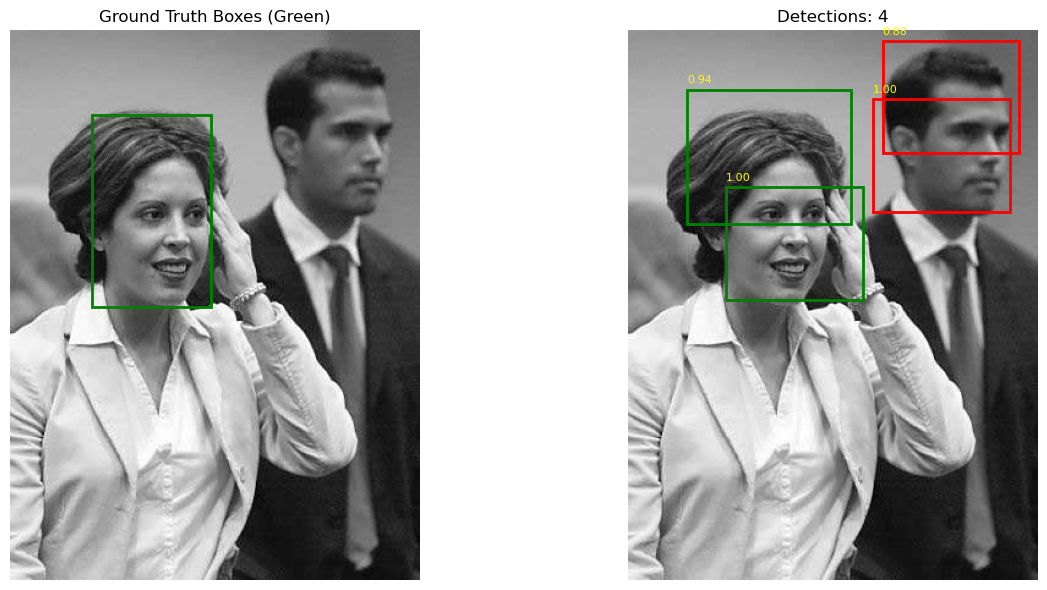

Evaluating:   0%|                                                                   | 2/2835 [00:18<7:06:23,  9.03s/it]


Image 2: img_135.jpg
  Ground Truth Faces: 1
  Detections: 4
  True Positives: 1
  False Positives: 3
  False Negatives: 0
  Recall for this image: 100.0%
Processing 7 pyramid levels...
  Level 0: (351, 450), found 3 candidates
  Level 1: (292, 375), found 3 candidates
  Level 2: (243, 312), found 0 candidates
  Level 3: (202, 260), found 0 candidates
  Level 4: (168, 216), found 0 candidates
  Level 5: (140, 180), found 0 candidates
  Level 6: (116, 150), found 0 candidates
Total candidates before NMS: 6
Final detections after NMS: 4


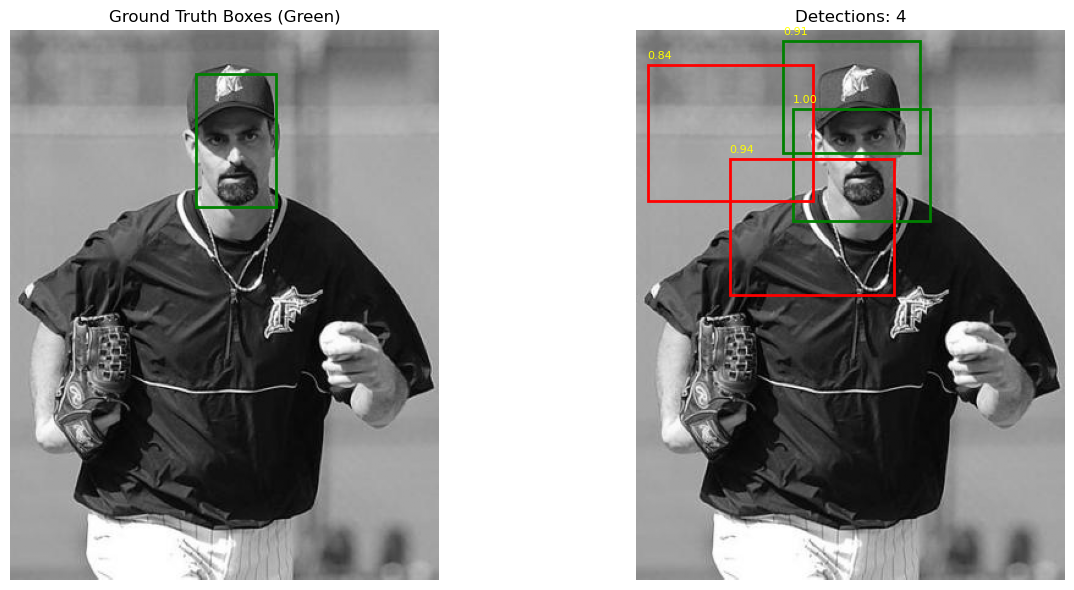

Evaluating:   0%|                                                                   | 3/2835 [00:27<7:09:23,  9.10s/it]


Image 3: img_141.jpg
  Ground Truth Faces: 1
  Detections: 4
  True Positives: 1
  False Positives: 3
  False Negatives: 0
  Recall for this image: 100.0%
Processing 7 pyramid levels...
  Level 0: (450, 321), found 25 candidates
  Level 1: (375, 267), found 12 candidates
  Level 2: (312, 222), found 7 candidates
  Level 3: (260, 185), found 0 candidates
  Level 4: (216, 154), found 0 candidates
  Level 5: (180, 128), found 0 candidates
  Level 6: (150, 106), found 0 candidates
Total candidates before NMS: 44
Final detections after NMS: 6


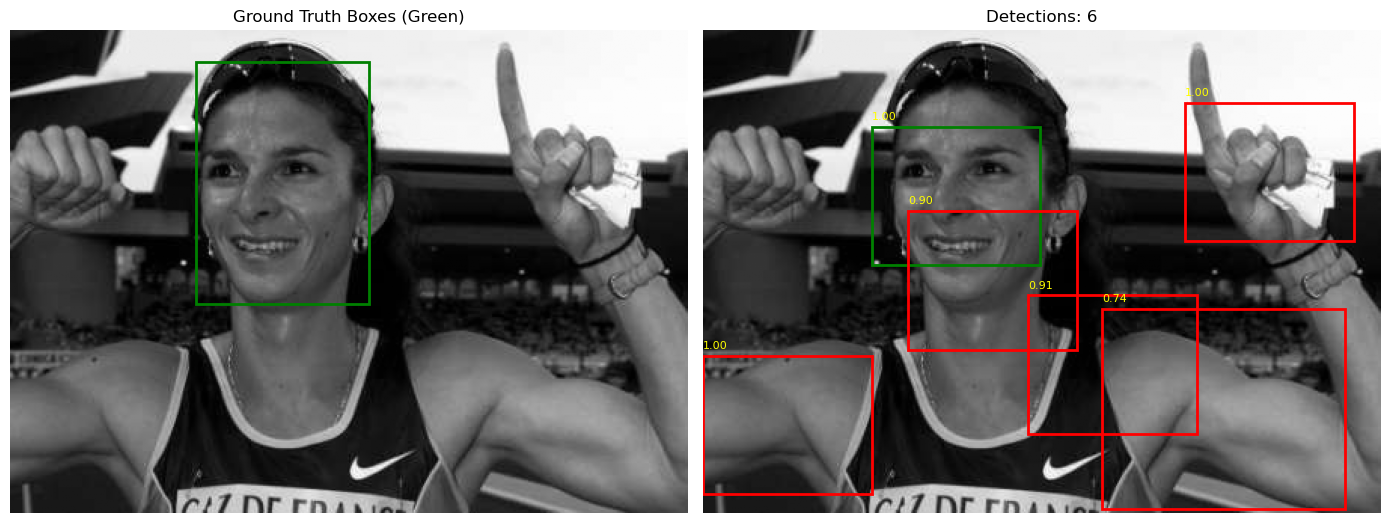

Evaluating:   0%|                                                                   | 4/2835 [00:35<6:56:05,  8.82s/it]


Image 4: img_158.jpg
  Ground Truth Faces: 1
  Detections: 6
  True Positives: 1
  False Positives: 5
  False Negatives: 0
  Recall for this image: 100.0%
Processing 8 pyramid levels...
  Level 0: (450, 362), found 1 candidates
  Level 1: (375, 301), found 0 candidates
  Level 2: (312, 250), found 0 candidates
  Level 3: (260, 208), found 0 candidates
  Level 4: (216, 173), found 0 candidates
  Level 5: (180, 144), found 0 candidates
  Level 6: (150, 120), found 0 candidates
  Level 7: (125, 100), found 0 candidates
Total candidates before NMS: 1
Final detections after NMS: 1


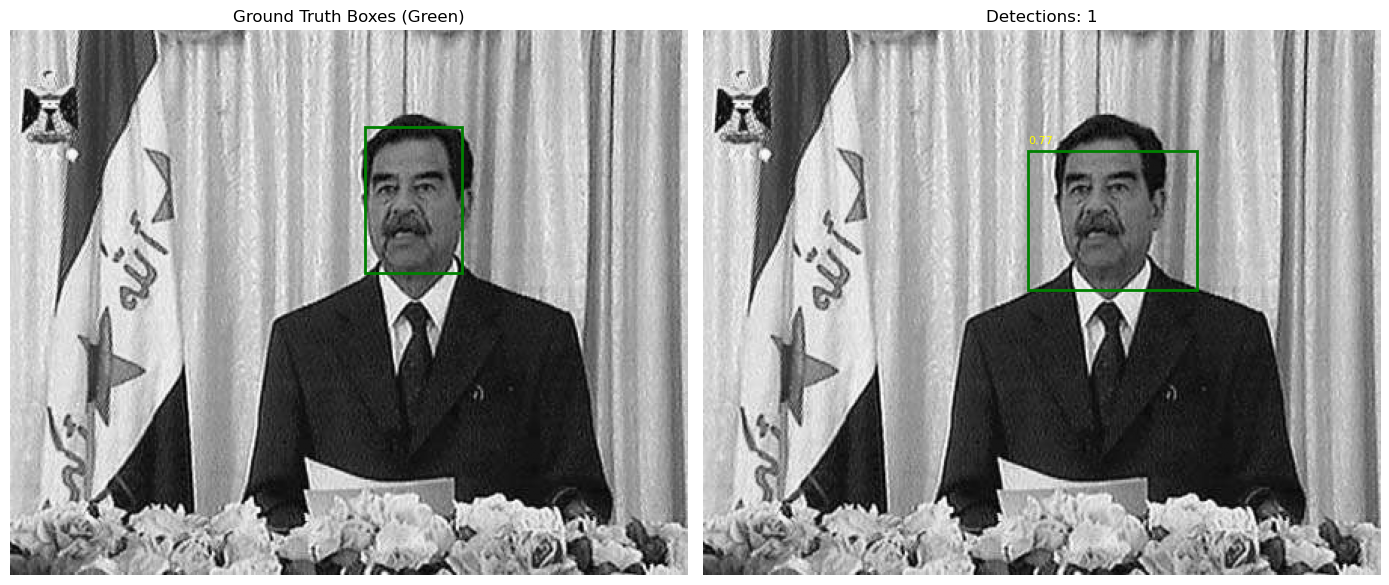

Evaluating:   0%|                                                                   | 5/2835 [00:45<7:13:30,  9.19s/it]


Image 5: img_160.jpg
  Ground Truth Faces: 1
  Detections: 1
  True Positives: 1
  False Positives: 0
  False Negatives: 0
  Recall for this image: 100.0%
Processing 7 pyramid levels...
  Level 0: (348, 450), found 10 candidates
  Level 1: (290, 375), found 6 candidates
  Level 2: (241, 312), found 0 candidates
  Level 3: (200, 260), found 0 candidates
  Level 4: (166, 216), found 0 candidates
  Level 5: (138, 180), found 0 candidates
  Level 6: (115, 150), found 0 candidates
Total candidates before NMS: 16
Final detections after NMS: 2


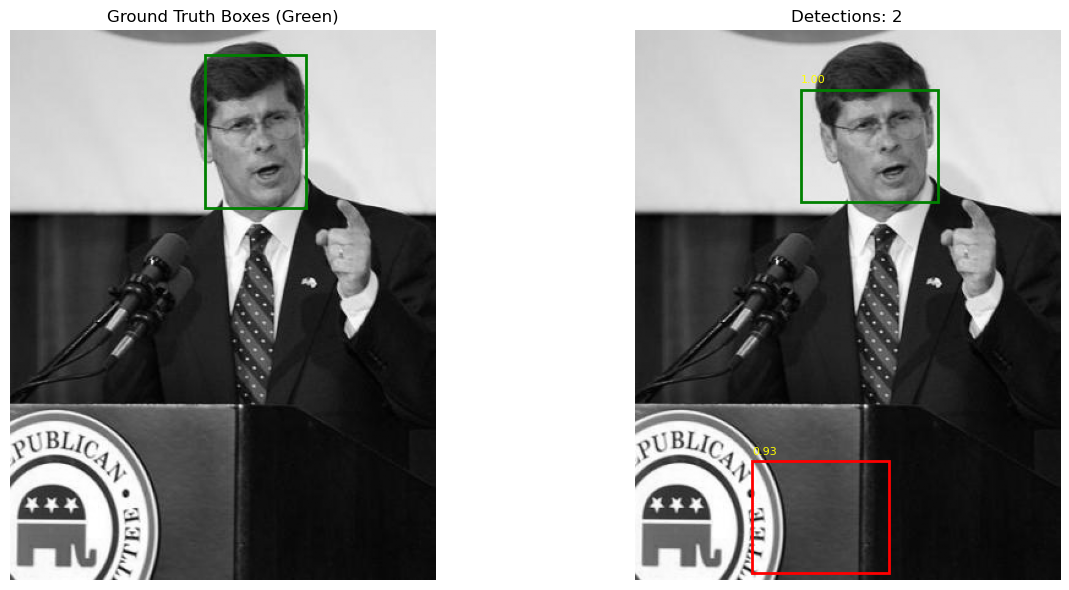

Evaluating:   0%|▏                                                                  | 6/2835 [00:54<7:06:40,  9.05s/it]


Image 6: img_18.jpg
  Ground Truth Faces: 1
  Detections: 2
  True Positives: 1
  False Positives: 1
  False Negatives: 0
  Recall for this image: 100.0%
Processing 6 pyramid levels...
  Level 0: (319, 450), found 15 candidates
  Level 1: (265, 375), found 12 candidates
  Level 2: (220, 312), found 7 candidates
  Level 3: (183, 260), found 2 candidates
  Level 4: (152, 216), found 0 candidates
  Level 5: (126, 180), found 0 candidates
Total candidates before NMS: 36
Final detections after NMS: 3


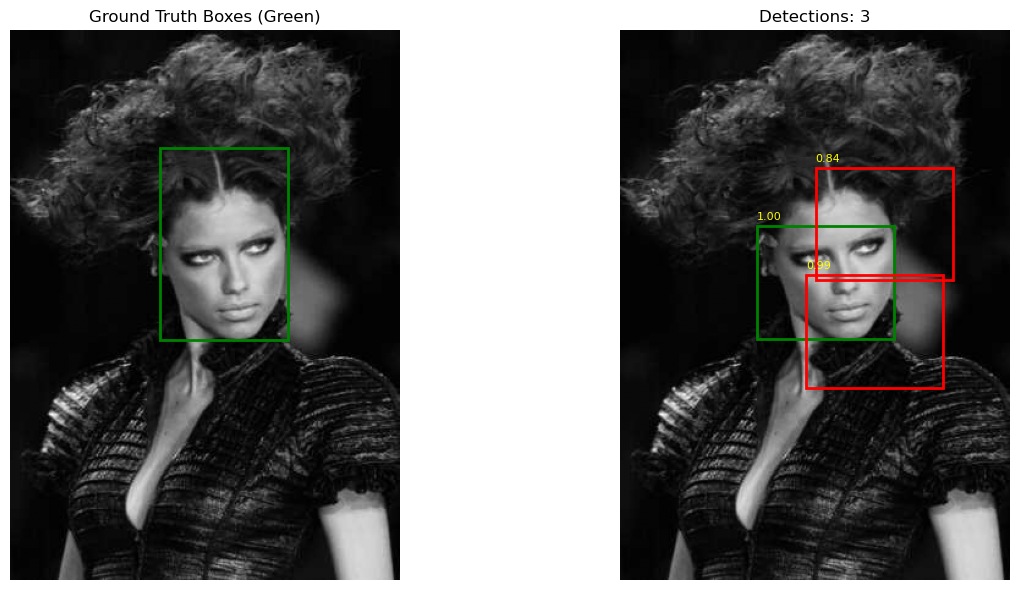

Evaluating:   0%|▏                                                                  | 7/2835 [01:01<6:43:27,  8.56s/it]


Image 7: img_198.jpg
  Ground Truth Faces: 1
  Detections: 3
  True Positives: 1
  False Positives: 2
  False Negatives: 0
  Recall for this image: 100.0%
Processing 7 pyramid levels...
  Level 0: (359, 450), found 58 candidates
  Level 1: (299, 375), found 47 candidates
  Level 2: (249, 312), found 25 candidates
  Level 3: (207, 260), found 8 candidates
  Level 4: (172, 216), found 5 candidates
  Level 5: (143, 180), found 0 candidates
  Level 6: (119, 150), found 0 candidates
Total candidates before NMS: 143
Final detections after NMS: 7


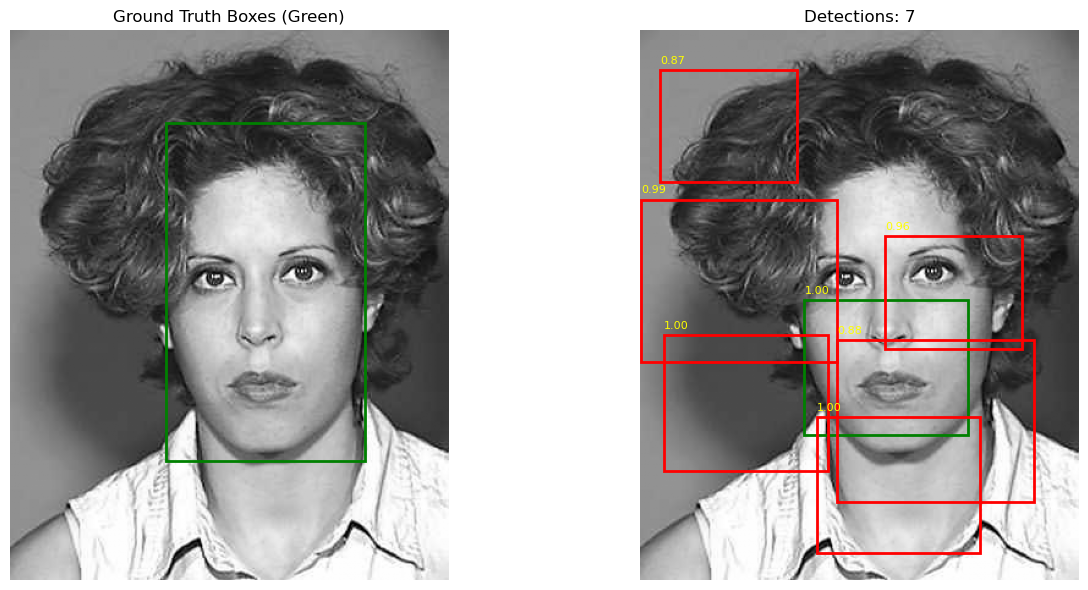

Evaluating:   0%|▏                                                                  | 8/2835 [01:11<6:53:46,  8.78s/it]


Image 8: img_209.jpg
  Ground Truth Faces: 1
  Detections: 7
  True Positives: 1
  False Positives: 6
  False Negatives: 0
  Recall for this image: 100.0%
Processing 6 pyramid levels...
  Level 0: (299, 449), found 49 candidates
  Level 1: (249, 374), found 45 candidates
  Level 2: (207, 311), found 41 candidates
  Level 3: (172, 259), found 38 candidates
  Level 4: (143, 215), found 25 candidates
  Level 5: (119, 179), found 6 candidates
Total candidates before NMS: 204
Final detections after NMS: 11


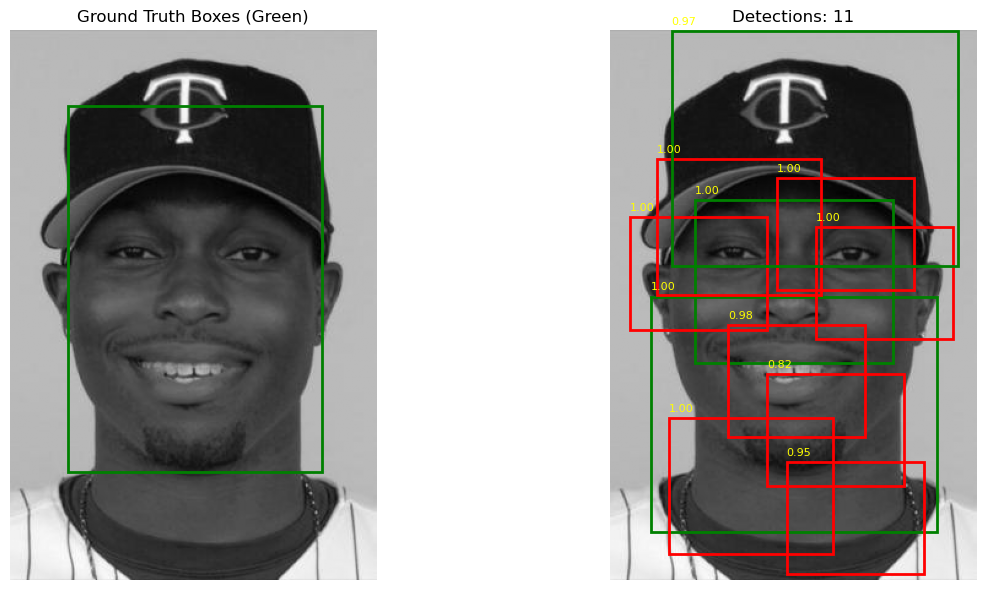

Evaluating:   0%|▏                                                                  | 9/2835 [01:18<6:32:19,  8.33s/it]


Image 9: img_230.jpg
  Ground Truth Faces: 1
  Detections: 11
  True Positives: 1
  False Positives: 10
  False Negatives: 0
  Recall for this image: 100.0%
Processing 6 pyramid levels...
  Level 0: (294, 450), found 33 candidates
  Level 1: (245, 375), found 28 candidates
  Level 2: (204, 312), found 14 candidates
  Level 3: (170, 260), found 8 candidates
  Level 4: (141, 216), found 0 candidates
  Level 5: (117, 180), found 0 candidates
Total candidates before NMS: 83
Final detections after NMS: 5


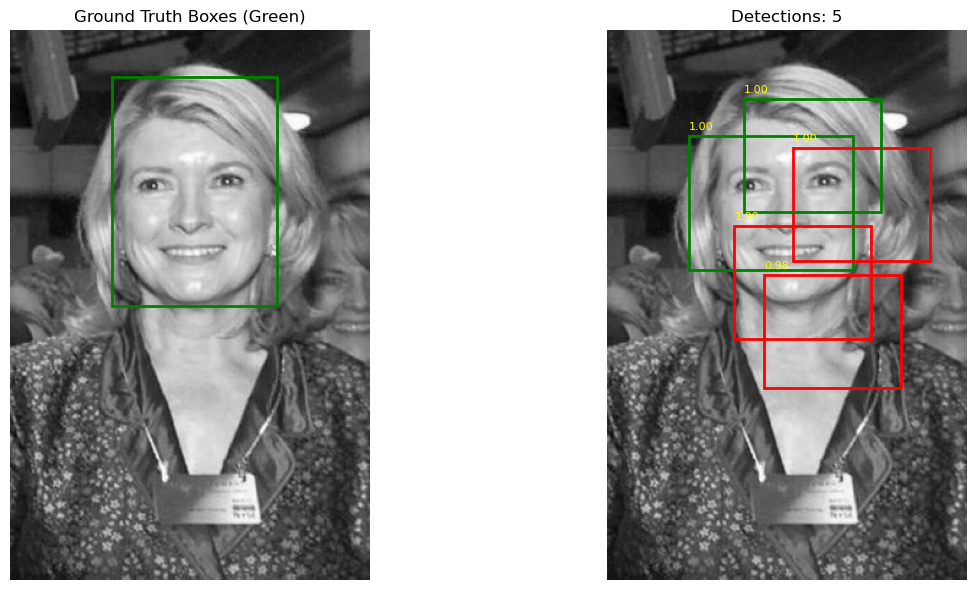

Evaluating:   0%|▏                                                                 | 10/2835 [01:25<6:41:10,  8.52s/it]


Image 10: img_247.jpg
  Ground Truth Faces: 1
  Detections: 5
  True Positives: 1
  False Positives: 4
  False Negatives: 0
  Recall for this image: 100.0%

DETECTION EVALUATION RESULTS
True Positives (correct detections): 9
False Positives (wrong detections): 39
False Negatives (missed faces): 1

Precision: 18.75% (how many detections were correct)
Recall: 90.00% (how many faces were found)
F1-Score: 31.03%

Non-face images:
  Correct (no false alarms): 0
  Wrong (false alarms): 0


In [84]:
# ============================================================
# CELL 3: Run Evaluation with Visualization
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

num_images = 10  # Number of images to test
iou_threshold = 0.3  # IoU threshold for considering a detection correct

# Counters
total_tp = 0  # True positives
total_fp = 0  # False positives
total_fn = 0  # False negatives
total_nonface_correct = 0
total_nonface_wrong = 0
processed = 0

for images, labels, gt_boxes_list, fpaths in tqdm(test_loader, desc="Evaluating"):
    if processed >= num_images:
        break
    
    image_tensor = images[0]
    label = labels[0].item()
    
    if len(gt_boxes_list) > 0 and len(gt_boxes_list[0]) > 0:
        raw_boxes = gt_boxes_list[0]
        gt_boxes = []
        
        # DataLoader flattens the boxes - group every 4 values back into a box
        if isinstance(raw_boxes, (list, tuple)):
            # raw_boxes is like [181, 36, 356, 285, 59, 19, 150, 154, ...]
            for i in range(0, len(raw_boxes), 4):
                if i + 3 < len(raw_boxes):
                    box = (int(raw_boxes[i]), int(raw_boxes[i+1]), 
                           int(raw_boxes[i+2]), int(raw_boxes[i+3]))
                    gt_boxes.append(box)
        else:
            # Fallback if already in correct format
            gt_boxes = [tuple(box) for box in raw_boxes]
    else:
        gt_boxes = []
    fpath = fpaths[0]
    
    # Convert to PIL
    image_pil = transforms.ToPILImage()(image_tensor.squeeze())
    
    # Detect faces
    detections = detect_faces(image_pil, model, score_threshold=0.7)
    
    # Evaluate based on image type
    if label == 1:  # Face image with ground truth
        tp, fp, fn = match_detections_to_gt(detections, gt_boxes, iou_threshold)
        total_tp += tp
        total_fp += fp
        total_fn += fn
    else:  # Non-face image
        if len(detections) == 0:
            total_nonface_correct += 1
        else:
            total_nonface_wrong += 1
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Original with ground truth
    axes[0].imshow(image_pil, cmap='gray')
    axes[0].set_title("Ground Truth Boxes (Green)")
    axes[0].axis('off')
    for gt_box in gt_boxes:
        x1, y1, x2, y2 = gt_box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor='green', facecolor='none')
        axes[0].add_patch(rect)
    
    # Detections
    axes[1].imshow(image_pil, cmap='gray')
    axes[1].set_title(f"Detections: {len(detections)}")
    axes[1].axis('off')
    
    # Color code detections: green = correct (TP), red = wrong (FP)
    if label == 1:
        for det in detections:
            x1, y1, x2, y2, score = det
            det_box = (x1, y1, x2, y2)
            
            # Check if this detection matches any GT box
            is_correct = False
            for gt_box in gt_boxes:
                if compute_iou(det_box, gt_box) >= iou_threshold:
                    is_correct = True
                    break
            
            color = 'green' if is_correct else 'red'
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                     linewidth=2, edgecolor=color, facecolor='none')
            axes[1].add_patch(rect)
            axes[1].text(x1, y1-5, f"{score:.2f}", color='yellow', fontsize=8)
    else:
        # Non-face image - all detections are false positives (red)
        for x1, y1, x2, y2, score in detections:
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                     linewidth=2, edgecolor='red', facecolor='none')
            axes[1].add_patch(rect)
            axes[1].text(x1, y1-5, f"{score:.2f}", color='yellow', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    if label == 1:
        print(f"\nImage {processed+1}: {os.path.basename(fpath)}")
        print(f"  Ground Truth Faces: {len(gt_boxes)}")
        print(f"  Detections: {len(detections)}")
        print(f"  True Positives: {tp}")
        print(f"  False Positives: {fp}")
        print(f"  False Negatives: {fn}")
        if len(gt_boxes) > 0:
            img_recall = tp / len(gt_boxes) * 100
            print(f"  Recall for this image: {img_recall:.1f}%")
    else:
        print(f"\nImage {processed+1}: Non-face image")
        print(f"  Detections: {len(detections)}")
        if len(detections) == 0:
            print(f"  Result: ✓ Correct (no false alarms)")
        else:
            print(f"  Result: ✗ Wrong (false alarm!)")
    processed += 1

"""
True Positive (TP): A detected box matches a ground truth box (IoU ≥ threshold).
False Positive (FP): A detected box does not match any ground truth box.
False Negative (FN): A ground truth face box does not have any detection matching it.
"""
# Calculate metrics
precision = total_tp / (total_tp + total_fp) * 100 if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) * 100 if (total_tp + total_fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\n" + "="*60)
print("DETECTION EVALUATION RESULTS")
print("="*60)
print(f"True Positives (correct detections): {total_tp}")
print(f"False Positives (wrong detections): {total_fp}")
print(f"False Negatives (missed faces): {total_fn}")
print(f"\nPrecision: {precision:.2f}% (how many detections were correct)")
print(f"Recall: {recall:.2f}% (how many faces were found)")
print(f"F1-Score: {f1_score:.2f}%")
print(f"\nNon-face images:")
print(f"  Correct (no false alarms): {total_nonface_correct}")
print(f"  Wrong (false alarms): {total_nonface_wrong}")
print("="*60)